TEST TEST TEST TEST LGBM

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, top_k_accuracy_score
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. LOAD DATA & DEFINE TARGET
# ==========================================
# Assuming df is already loaded
target_col = 'Receiving Country'
cols_to_drop = [target_col, 'Receiving City', 'Receiving Organization', 'Unnamed: 0']

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df[target_col]

# Drop target NaNs and encode target labels
mask = y.notna()
X, y = X[mask], y[mask]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ==========================================
# 2. FILTER FOR TOP 15 CLASSES ONLY
# ==========================================
K = 15  # Number of classes to keep

y_series = pd.Series(y_encoded)
top_k_classes = y_series.value_counts().nlargest(K).index

# Create a boolean mask of rows that belong to the top K classes
mask_top15 = y_series.isin(top_k_classes).values

# Apply mask to filter X and y
X = X.iloc[mask_top15].copy()
y_encoded = np.array(y_encoded)[mask_top15]

# Fit a new LabelEncoder specifically for these top 15 classes so IDs map cleanly from 0 to 14
# (We map back using the filtered original string labels)
filtered_countries = le.inverse_transform(y_encoded)
le_top15 = LabelEncoder()
y_encoded = le_top15.fit_transform(filtered_countries)

print(f"Filtered dataset shape: {X.shape}")
print(f"Number of target classes: {len(le_top15.classes_)}")

# ==========================================
# 3. CONVERT CATEGORICALS TO PANDAS 'CATEGORY'
# ==========================================
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype('category')

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# ==========================================
# 4. SPLIT & SUBSAMPLE FOR SPEED
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 10% stratified sample for fast hyperparameter search
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, 
    train_size=0.10, 
    stratify=y_train, 
    random_state=42
)

# ==========================================
# 5. CONFIGURE LIGHTGBM & RANDOM SEARCH
# ==========================================
lgb_estimator = LGBMClassifier(
    objective='multiclass',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    device = 'cpu'
)

param_dist_lgb = {
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [300, 500, 800],
    'num_leaves': [31, 63, 127],       
    'max_depth': [-1, 15, 25],         
    'min_child_samples': [20, 50, 100],
    'reg_lambda': [0.0, 0.1, 1.0]      
}

random_search = RandomizedSearchCV(
    estimator=lgb_estimator,
    param_distributions=param_dist_lgb,
    n_iter=15,             
    scoring='f1_weighted', 
    cv=3,               
    n_jobs=-1,          
    verbose=2,
    random_state=42
)

print("\nStarting LightGBM hyperparameter search on 10% sample...")
random_search.fit(X_train_sample, y_train_sample)
print(f"Best Parameters: {random_search.best_params_}")

# ==========================================
# 6. TRAIN FINAL MODEL ON FULL DATA
# ==========================================
print("\nTraining final LightGBM model on full dataset...")
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)
print("Training complete!")

# ==========================================
# 7. EVALUATE PERFORMANCE
# ==========================================
y_pred = best_model.predict(X_test)
print("\n--- Standard Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le_top15.classes_))

y_prob = best_model.predict_proba(X_test)
top3_acc = top_k_accuracy_score(y_test, y_prob, k=3)
print(f"\n--- Recommender System Metric ---")
print(f"Top-3 Accuracy: {top3_acc:.2%}")

Filtered dataset shape: (2632839, 12)
Number of target classes: 15

Starting LightGBM hyperparameter search on 10% sample...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters: {'reg_lambda': 0.1, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 50, 'max_depth': 15, 'learning_rate': 0.05}

Training final LightGBM model on full dataset...
Training complete!

--- Standard Classification Report ---
                precision    recall  f1-score   support

       Austria       0.38      0.17      0.24     17215
       Belgium       0.37      0.19      0.25     25002
       Finland       0.43      0.32      0.37     16483
        France       0.44      0.45      0.45     56960
       Germany       0.43      0.45      0.44     62875
       Hungary       0.56      0.25      0.34     11926
       Ireland       0.47      0.28      0.35     14939
         Italy       0.40      0.42      0.41     57635
   Netherlands       0.39      0.30      0.34     27363
   

Filtered dataset shape: (2632839, 12)
Number of target classes: 15

Starting LightGBM hyperparameter search on 10% sample...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters: {'reg_lambda': 0.1, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 50, 'max_depth': 15, 'learning_rate': 0.05}

Training final LightGBM model on full dataset...
Training complete!

--- Standard Classification Report ---
                precision    recall  f1-score   support

       Austria       0.38      0.17      0.24     17215
       Belgium       0.37      0.19      0.25     25002
       Finland       0.43      0.32      0.37     16483
        France       0.44      0.45      0.45     56960
       Germany       0.43      0.45      0.44     62875
       Hungary       0.56      0.25      0.34     11926
       Ireland       0.47      0.28      0.35     14939
         Italy       0.40      0.42      0.41     57635
   Netherlands       0.39      0.30      0.34     27363
        Norway       0.42      0.29      0.34     14965
        Poland       0.50      0.48      0.49     30991
      Portugal       0.40      0.19      0.26     30954
...


--- Recommender System Metric ---
Top-3 Accuracy: 71.45%

XGBOOST XGBOOST

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from xgboost import XGBClassifier

# ==========================================
# 1. FEATURE ENGINEERING & DATA PREP
# ==========================================
df['Duration_Months'] = (df['Mobility Duration'] / 30.44).round() # n. of months, kinda

X = df.drop(columns=['Receiving Country', 'Receiving City', 'Receiving Organization'], errors='ignore')
y = df['Receiving Country'] 

# Drop target NaNs and encode target labels first
mask_y = y.notna()
X = X[mask_y]
y = y[mask_y]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ==========================================
# 2. FILTER FOR TOP 15 CLASSES
# ==========================================
K = 15  # Number of classes to keep

y_series = pd.Series(y_encoded)
top_k_classes = y_series.value_counts().nlargest(K).index

# Create a boolean mask of rows belonging to top K classes
mask = y_series.isin(top_k_classes).values

# Apply mask to filter X and y_encoded
X = X.iloc[mask].copy()
y_filtered = np.array(y_encoded)[mask] 

# Re-encode filtered labels cleanly from 0 to 14
le_top15 = LabelEncoder()
y_encoded_final = le_top15.fit_transform(le.inverse_transform(y_filtered))

# Define your columns
cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Detected {len(num_cols)} numerical features and {len(cat_cols)} categorical features.")

# Fix pandas NA & mixed strings
X[cat_cols] = X[cat_cols].fillna(value=np.nan)
for col in cat_cols:
    X[col] = X[col].apply(lambda x: str(x) if not pd.isna(x) else x)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded_final, train_size=0.4, stratify=y_encoded_final, random_state=42
)

# ==========================================
# 3. BUILD THE PREPROCESSOR
# ==========================================
# Numerical Pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical Pipeline (Strict order: Impute -> Encode)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# ==========================================
# 4. INITIALIZE XGBOOST CLASSIFIER & PIPELINE
# ==========================================
# Initialize XGBClassifier 
# Note: You can switch device='cuda' if you want GPU acceleration, or 'cpu'
xgb_estimator = XGBClassifier(
    objective='multi:softprob',
    tree_method='hist',
    device='cuda',            # Set to 'cpu' if you prefer CPU execution
    random_state=42,
    n_jobs=-1
)

# Create the final unified pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_estimator)
])

# ==========================================
# 5. HYPERPARAMETER SEARCH (XGBOOST GRID)
# ==========================================
param_dist_xgb = {
    'classifier__learning_rate': [0.03, 0.05, 0.1, 0.2],
    'classifier__n_estimators': [300, 500, 800],            
    'classifier__max_depth': [6, 10, 15, 20],        
    'classifier__min_child_weight': [1, 5, 10],      
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__reg_lambda': [0.0, 1.0, 5.0]     
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist_xgb,
    n_iter=15,             
    scoring='f1_weighted', 
    cv=3,                         
    verbose=2,
    random_state=42
)

# ==========================================
# 6. EXECUTE TRAINING
# ==========================================
print("Starting XGBoost training...")
random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best F1 Weighted Score: {random_search.best_score_}")

Old Implementation of the original Random Forest methods

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score
import numpy as np
import pandas as pd

# 0. Filter to keep only Top K
K = 15  # Set this to the number of classes you want to keep

# Convert y_encoded to a pandas Series to easily find the most frequent classes
y_series = pd.Series(y_encoded)
top_k_classes = y_series.value_counts().nlargest(K).index

# Create a boolean mask of rows that belong to the top K classes
mask = y_series.isin(top_k_classes).values

# Apply mask to filter X and y (assuming X is a pandas DataFrame)
X_filtered = X.iloc[mask].copy()
y_filtered = np.array(y_encoded)[mask]  # Convert to numpy array for safe indexing later


# 1. Main Train/Test Split (80/20)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_filtered, y_filtered, test_size=0.20, random_state=42, stratify=y_filtered)


# 1. Apply Imputers (assuming fit_transform_imputers is defined earlier in your code)
X_train_proc, X_test_proc = fit_transform_imputers(X_train_full, X_test_full)

# 2. Categorical Encoding (assuming encoder and cat_features are defined)
X_train_proc[cat_features] = encoder.fit_transform(X_train_proc[cat_features])
X_test_proc[cat_features] = encoder.transform(X_test_proc[cat_features])

# 3. Setup Hyperparameter Grid
param_dist = {
    'n_estimators': [150, 200, 250],
    'max_samples': [0.1, 0.25, 0.40],
    'max_depth': [20, 25, 35, None],
    'min_samples_leaf': [5, 15, 30],
    'min_samples_split': [10, 30, 60],
    'max_features': ['sqrt', 0.2, None],
    'class_weight': ['balanced', 'balanced_subsample']
}

# 4. Initialize Search
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=15,                 # Tries 15 random combinations
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("\n--- Running Automated 3-CV Search ---")

# Cast all numeric float columns to float32 and int columns to int32
X_train_proc = X_train_proc.astype({
    col: 'float32' if dtype == 'float64' else 'int32' 
    for col, dtype in X_train_proc.dtypes.items() if dtype in ['float64', 'int64']
})

search.fit(X_train_proc, y_train_full)

print("\n--- Optimal Parameters Found ---")
for param, val in search.best_params_.items():
    print(f"  {param}: {val}")

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# Separate target and features
y = df['Receiving Country']
X = df.drop(columns=['Receiving Country', 'Receiving City', 'Receiving Organization'])
print(X.columns)

# Encode Target Variable
le = LabelEncoder()
# Drop target NaNs if any exist before encoding
mask = y.notna()
X, y = X[mask], y[mask]
y_encoded = le.fit_transform(y)

# Identify categorical features
cat_features = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

# Use OrdinalEncoder with handling for unknown categories in test sets
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

In [ ]:
def fit_transform_imputers(df_train, df_val=None):
    """
    Fits imputation rules strictly on df_train and transforms both train and val/test sets.
    """
    df_tr = df_train.copy()
    df_v = df_val.copy() if df_val is not None else None

    # 1. Mobility Duration -> Impute with median per Education Level
    duration_medians = df_tr.groupby('Education Level')['Mobility Duration'].transform('median')
    global_duration_median = df_tr['Mobility Duration'].median()
    
    df_tr['Mobility Duration'] = df_tr['Mobility Duration'].fillna(duration_medians).fillna(global_duration_median)
    if df_v is not None:
        val_duration_medians = df_v['Education Level'].map(df_tr.groupby('Education Level')['Mobility Duration'].median())
        df_v['Mobility Duration'] = df_v['Mobility Duration'].fillna(val_duration_medians).fillna(global_duration_median)

    # 2. Categorical columns -> Impute missing entries with 'Unknown'
    cat_cols = ['Field of Education', 'Participant Country', 'Fewer Opportunities', 
                'Sending Organization', 'Receiving Organization', 'Receiving City']
    
    for col in cat_cols:
        if col in df_tr.columns:
            df_tr[col] = df_tr[col].fillna('Unknown')
            if df_v is not None:
                df_v[col] = df_v[col].fillna('Unknown')

    return (df_tr, df_v) if df_val is not None else df_tr

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_erasmus_confusion_matrix(X_test, y_test, model, label_encoder):
    """
    Computes and plots a confusion matrix for the multiclass classification model,
    matching the requested style with country labels and a blue heatmap gradient.
    """
    # 1. Generate predictions on the test set
    y_pred_encoded = model.predict(X_test)
    
    # 2. Compute the confusion matrix using encoded integer labels
    cm = confusion_matrix(y_test, y_pred_encoded)
    
    # 3. Retrieve the ordered class names from the LabelEncoder
    class_names = label_encoder.classes_
    
    # 4. Plot the confusion matrix
    plt.figure(figsize=(12, 10))
    
    ax = sns.heatmap(
        cm, 
        annot=True,              # Show numbers inside the cells
        fmt='d',                 # Format as integers
        cmap='Blues',            # Blue sequential colormap matching your image
        cbar=True,               # Show colorbar on the right
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,          # Subtle grid lines between cells
        linecolor='#e0e0e0'
    )
    
    # 5. Styling and labels
    plt.title('Confusion Matrix for Top K Classes', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Predicted label', fontsize=11, labelpad=10, fontweight='bold')
    plt.ylabel('True label', fontsize=11, labelpad=10, fontweight='bold')
    
    # Rotate x-axis labels for readability
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Generate and display the confusion matrix heatmap
plot_erasmus_confusion_matrix(
    X_test=X_test, 
    y_test=y_test, 
    model= random_search, 
    label_encoder=le
)

KeyboardInterrupt: 

Now that we hae the parameters, we can apply them to the model and see the results.

In [ ]:
# 1. Full Imputation
X_train_clean, X_test_clean = fit_transform_imputers(X_train_full, X_test_full)

# 2. Full Categorical Encoding
X_train_clean[cat_features] = encoder.fit_transform(X_train_clean[cat_features])
X_test_clean[cat_features] = encoder.transform(X_test_clean[cat_features])

# Downcast floats/ints to save memory on 3M rows
for col in X_train_clean.select_dtypes('float64').columns:
    X_train_clean[col] = X_train_clean[col].astype('float32')
    X_test_clean[col] = X_test_clean[col].astype('float32')

# 3. Train Final Scaled Model
final_rf = RandomForestClassifier( **search.best_params_ )

final_rf.fit(X_train_clean, y_train_full)

# 4. Final Evaluation
y_pred = final_rf.predict(X_test_clean)
print("Final Test Set Macro F1:", f1_score(y_test_full, y_pred, average='macro'))

Final Test Set Macro F1: 0.25524919437131377



--- Final Model Parameters ---
bootstrap: True
ccp_alpha: 0.0
class_weight: balanced_subsample
criterion: gini
max_depth: 20
max_features: None
max_leaf_nodes: None
max_samples: 0.1
min_impurity_decrease: 0.0
min_samples_leaf: 5
min_samples_split: 10
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 150
n_jobs: None
oob_score: False
random_state: None
verbose: 0
warm_start: False

Training final model on full 80% train set...

--- Final Evaluation on Unseen Test Data ---
              precision    recall  f1-score   support

           8       0.16      0.22      0.19     17215
          13       0.20      0.23      0.21     25002
          58       0.21      0.36      0.27     16483
          59       0.40      0.29      0.34     56960
          63       0.40      0.29      0.33     62875
          75       0.27      0.24      0.25     11926
          81       0.22      0.35      0.27     14939
          83       0.39      0.25      0.31     57635
         116       0.2

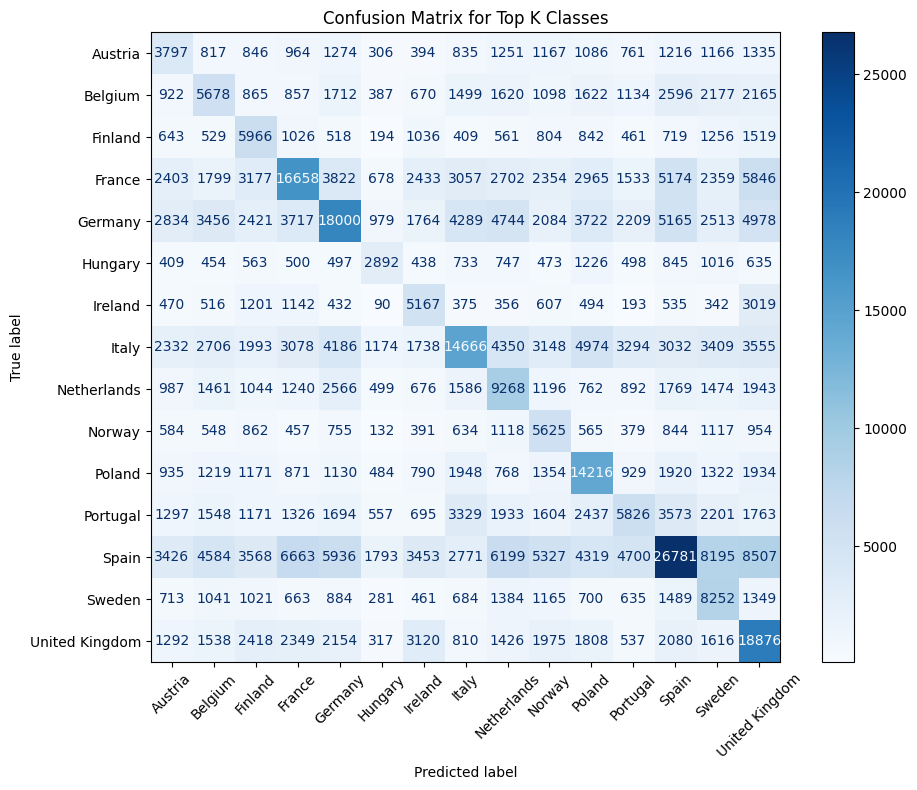

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 4. Final Evaluation on 20% Holdout Set
# ---------------------------------------------------------

# A. Prepare the full 80% train and 20% test sets
# (Apply the same imputation and encoding steps used in the CV loop)
X_train_final, X_test_final = fit_transform_imputers(X_train_full, X_test_full)

X_train_final[cat_features] = encoder.fit_transform(X_train_final[cat_features])
X_test_final[cat_features] = encoder.transform(X_test_final[cat_features])

# B. Initialize the model and check the parameters
final_rf = RandomForestClassifier(
    **search.best_params_
)

print("\n--- Final Model Parameters ---")
for param, value in final_rf.get_params().items():
    print(f"{param}: {value}")

# C. Train on the full 80% data
print("\nTraining final model on full 80% train set...")
final_rf.fit(X_train_final, y_train_full)

# D. Predict on the 20% unseen test data
final_preds = final_rf.predict(X_test_final)

y_test_text = le.inverse_transform(np.array(y_test_full).ravel())
final_preds_text = le.inverse_transform(np.array(final_preds).ravel())

# E. Assess the "Goodness" of the results
print("\n--- Final Evaluation on Unseen Test Data ---")
print(classification_report(y_test_full, final_preds))

# F. Plot Confusion Matrix (Optional but highly recommended for multi-class)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_text, 
    final_preds_text, 
    ax=ax, 
    cmap='Blues',
    xticks_rotation=45
)
plt.title("Confusion Matrix for Top K Classes")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, top_k_accuracy_score
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. LOAD DATA & DEFINE TARGET
# ==========================================
# Assuming df is already loaded
target_col = 'Receiving Country'
cols_to_drop = [target_col, 'Receiving City', 'Receiving Organization', 'Unnamed: 0']

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df[target_col]

# Drop target NaNs and encode target labels
mask = y.notna()
X, y = X[mask], y[mask]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ==========================================
# 2. FILTER FOR TOP 15 CLASSES ONLY
# ==========================================
K = 15  # Number of classes to keep

y_series = pd.Series(y_encoded)
top_k_classes = y_series.value_counts().nlargest(K).index

# Create a boolean mask of rows that belong to the top K classes
mask_top15 = y_series.isin(top_k_classes).values

# Apply mask to filter X and y
X = X.iloc[mask_top15].copy()
y_encoded = np.array(y_encoded)[mask_top15]

# Fit a new LabelEncoder specifically for these top 15 classes so IDs map cleanly from 0 to 14
# (We map back using the filtered original string labels)
filtered_countries = le.inverse_transform(y_encoded)
le_top15 = LabelEncoder()
y_encoded = le_top15.fit_transform(filtered_countries)

print(f"Filtered dataset shape: {X.shape}")
print(f"Number of target classes: {len(le_top15.classes_)}")

# ==========================================
# 3. CONVERT CATEGORICALS TO PANDAS 'CATEGORY'
# ==========================================
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype('category')

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# ==========================================
# 4. SPLIT & SUBSAMPLE FOR SPEED
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 10% stratified sample for fast hyperparameter search
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, 
    train_size=0.10, 
    stratify=y_train, 
    random_state=42
)

# ==========================================
# 5. CONFIGURE LIGHTGBM & RANDOM SEARCH
# ==========================================
lgb_estimator = LGBMClassifier(
    objective='multiclass',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    device = 'cpu'
)

param_dist_lgb = {
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [300, 500, 800],
    'num_leaves': [31, 63, 127],       
    'max_depth': [-1, 15, 25],         
    'min_child_samples': [20, 50, 100],
    'reg_lambda': [0.0, 0.1, 1.0]      
}

random_search = RandomizedSearchCV(
    estimator=lgb_estimator,
    param_distributions=param_dist_lgb,
    n_iter=15,             
    scoring='f1_weighted', 
    cv=3,               
    n_jobs=-1,          
    verbose=2,
    random_state=42
)

print("\nStarting LightGBM hyperparameter search on 10% sample...")
random_search.fit(X_train_sample, y_train_sample)
print(f"Best Parameters: {random_search.best_params_}")

# ==========================================
# 6. TRAIN FINAL MODEL ON FULL DATA
# ==========================================
print("\nTraining final LightGBM model on full dataset...")
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)
print("Training complete!")

# ==========================================
# 7. EVALUATE PERFORMANCE
# ==========================================
y_pred = best_model.predict(X_test)
print("\n--- Standard Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le_top15.classes_))

y_prob = best_model.predict_proba(X_test)
top3_acc = top_k_accuracy_score(y_test, y_prob, k=3)
print(f"\n--- Recommender System Metric ---")
print(f"Top-3 Accuracy: {top3_acc:.2%}")

Filtered dataset shape: (2632839, 12)
Number of target classes: 15

Starting LightGBM hyperparameter search on 10% sample...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters: {'reg_lambda': 0.1, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 50, 'max_depth': 15, 'learning_rate': 0.05}

Training final LightGBM model on full dataset...
Training complete!

--- Standard Classification Report ---
                precision    recall  f1-score   support

       Austria       0.38      0.17      0.24     17215
       Belgium       0.37      0.19      0.25     25002
       Finland       0.43      0.32      0.37     16483
        France       0.44      0.45      0.45     56960
       Germany       0.43      0.45      0.44     62875
       Hungary       0.56      0.25      0.34     11926
       Ireland       0.47      0.28      0.35     14939
         Italy       0.40      0.42      0.41     57635
   Netherlands       0.39      0.30      0.34     27363
   

In [ ]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from matplotlib.ticker import PercentFormatter

# ==========================================
# STEP 5: BETTER RESULT VISUALIZATIONS
# ==========================================
print("\n" + "="*40)
print(" STEP 5: VISUALIZING CLASSIFIER BEHAVIOR")
print("="*40)

# We need the unique class labels in order for ROC curve plotting
# Get sorted unique labels actually present in the test set
unique_classes = sorted(np.unique(y_test_text))
n_classes = len(unique_classes)

# ---------------------------------------------------------
# A. Visual Actual vs. Predicted Distribution
# ---------------------------------------------------------
# Instead of a table, let's visualize the "bias" DataFrame from before.

# Reuse the distribution logic from last time (ensuring same sorting)
actual_counts = pd.Series(y_test_text).value_counts().sort_index()
predicted_counts = pd.Series(final_preds_text).value_counts().sort_index()

distribution_df = pd.DataFrame({
    'Actual Actuals': actual_counts,
    'Model Predicted': predicted_counts
}).fillna(0)

distribution_df = distribution_df.melt(var_name='Type', value_name='Count', ignore_index=False)
distribution_df.reset_index(inplace=True)
distribution_df.rename(columns={'index': 'Country'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=distribution_df, x='Country', y='Count', hue='Type', palette=['#4e79a7', '#e15759'])
plt.title('Actual vs. Model Predicted Frequency per Country')
plt.ylabel('Number of People')
plt.xlabel('Destination Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# B. Prediction Probability Distribution (Separation Plot)
# ---------------------------------------------------------
# A robust model has "high" probabilities for correct answers
# and "low" probabilities for wrong answers. We want a clear gap.

# confidence_df was created in the last step
confidence_df = pd.DataFrame({
    'Confidence': np.max(final_rf.predict_proba(X_test_final), axis=1),
    'Correct': (final_preds == y_test_full)
})

plt.figure(figsize=(10, 5))
# KDE plot of confidence, separated by correctness
sns.kdeplot(data=confidence_df[confidence_df['Correct'] == True], x='Confidence', 
            fill=True, label='Correct Predictions', color='#4e79a7', alpha=0.6)
sns.kdeplot(data=confidence_df[confidence_df['Correct'] == False], x='Confidence', 
            fill=True, label='Incorrect Predictions', color='#e15759', alpha=0.6)

plt.title('How Confident is the Model When it is Wrong?')
plt.xlabel('Probability of Chosen Class')
plt.ylabel('Density')
plt.legend()
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()


 STEP 5: VISUALIZING CLASSIFIER BEHAVIOR


NameError: name 'y_test_text' is not defined

Detected 4 numerical features and 8 categorical features.
Starting training...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters: {'classifier__min_samples_leaf': 100, 'classifier__max_leaf_nodes': 254, 'classifier__max_iter': 800, 'classifier__max_depth': 35, 'classifier__learning_rate': 0.01, 'classifier__l2_regularization': 0.1}
Best F1 Macro Score: 0.3748438905513147

Data from RandomSearch on 40% of the dataset as training data

In [ ]:
# ==========================================
# STEP 4: Evaluate Best Model
# ==========================================
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



best_rf = search.best_estimator_

print("\n--- Optimal Parameters Found ---")
for param, val in search.best_params_.items():
    print(f"  {param}: {val}")

# Final Predictions
final_preds = best_rf.predict(X_test_proc)

print(classification_report(y_test_full, final_preds))


# Decode target numbers back into Country String Names
y_test_text = le.inverse_transform(np.array(y_test_full).ravel()).astype(str)
final_preds_text = le.inverse_transform(np.array(final_preds).ravel()).astype(str)

print("\n--- Final Classification Report ---")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_text,
    final_preds_text,
    ax=ax,
    cmap='Blues',
    xticks_rotation=45
)
plt.xticks(ha='right')
plt.title("Optimized Confusion Matrix", fontsize=12, pad=15)
plt.tight_layout()
plt.show()